# 銀行の顧客ターゲティング（改良版）
- 生成日時: 2025-11-12 00:08
- 目的: 応答予測タスクの再現性・比較性・可読性を高めたテンプレート
- 入力データの既定パス: `./data/train.csv`（必要に応じて変更してください）


## 目次
1. 設定（乱数やパス）
2. ライブラリのインポート
3. ユーティリティ関数（評価・プロット）
4. データ読み込み & 概要確認
5. 前処理パイプライン（欠損・カテゴリ・スケーリング）
6. 学習・評価（ロジスティック回帰 / ランダムフォレスト / 勾配ブースティング / XGBoost / LightGBM / CatBoost）
7. 比較サマリー & 保存
8. 提出用予測出力（サブミット作成）


In [1]:

# ==== 1. 設定 ====
RANDOM_STATE = 42
TEST_SIZE = 0.2
DATA_PATH = "./data/train.csv"  # 必要なら変更
TARGET_COL = "y"  # 目的変数名（必要に応じて変更）


In [2]:

# ==== 2. ライブラリのインポート ====
import warnings
warnings.filterwarnings("once")  # 警告は一括無視しない（重要なものは1回表示）

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


In [3]:

# ==== 3. ユーティリティ関数 ====
def evaluate_binary_classification(y_true, y_prob, threshold=0.5):
    """Compute common metrics given probas and a threshold."""
    import numpy as np
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }

def plot_roc(y_true, y_prob, label=None):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, lw=2, label=label if label else "ROC")
    plt.plot([0,1],[0,1],'--', lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    if label:
        plt.legend(loc="lower right")
    plt.show()

def plot_pr(y_true, y_prob, label=None):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.figure()
    plt.plot(recall, precision, lw=2, label=label if label else "PR")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    if label:
        plt.legend(loc="lower left")
    plt.show()


In [4]:

# ==== 4. データ読み込み & 概要確認 ====
if not os.path.exists(DATA_PATH):
    print(f"[WARN] データファイルが見つかりません: {DATA_PATH}")
    print("パスを修正して再実行してください。")
df = pd.read_csv(DATA_PATH) if os.path.exists(DATA_PATH) else pd.DataFrame()

print("Shape:", df.shape)
display(df.head(3) if not df.empty else df)

if not df.empty:
    # 目的変数が0/1でない場合に備えた簡易変換
    if df[TARGET_COL].dtype == "O":
        # yes/noや文字列の2値を0/1へ
        df[TARGET_COL] = df[TARGET_COL].astype(str).str.lower().map({"yes":1,"no":0}).fillna(df[TARGET_COL])
    # 数値でないが2値っぽいならカテゴリ→0/1
    if df[TARGET_COL].dtype == "O" and df[TARGET_COL].nunique() == 2:
        mapping = {k:i for i,k in enumerate(sorted(df[TARGET_COL].unique()))}
        df[TARGET_COL] = df[TARGET_COL].map(mapping)

    # 基本統計
    print("\n=== 欠損サマリー ===")
    display(df.isna().sum().sort_values(ascending=False).head(20))

    print("\n=== 目的変数分布 ===")
    display(df[TARGET_COL].value_counts(dropna=False))


Shape: (27128, 18)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,1,39,blue-collar,married,secondary,no,1756,yes,no,cellular,3,apr,939,1,-1,0,unknown,1
1,2,51,entrepreneur,married,primary,no,1443,no,no,cellular,18,feb,172,10,-1,0,unknown,1
2,3,36,management,single,tertiary,no,436,no,no,cellular,13,apr,567,1,595,2,failure,1



=== 欠損サマリー ===


id           0
age          0
poutcome     0
previous     0
pdays        0
campaign     0
duration     0
month        0
day          0
contact      0
loan         0
housing      0
balance      0
default      0
education    0
marital      0
job          0
y            0
dtype: int64


=== 目的変数分布 ===


y
0    23954
1     3174
Name: count, dtype: int64

In [5]:

# ==== 5. 前処理パイプライン ====
if not df.empty:
    y = df[TARGET_COL].astype(int)
    X = df.drop(columns=[TARGET_COL])

    # 推定: 数値/カテゴリ列を自動判定
    numeric_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
    categorical_features = [c for c in X.columns if c not in numeric_features]

    numeric_transformer = Pipeline(steps=[
        ("scaler", StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (21702, 17)  Test: (5426, 17)


[LogReg] best_params: {'clf__C': 0.1}  ROC_AUC: 0.9009096780873587


c:\Users\ssshu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


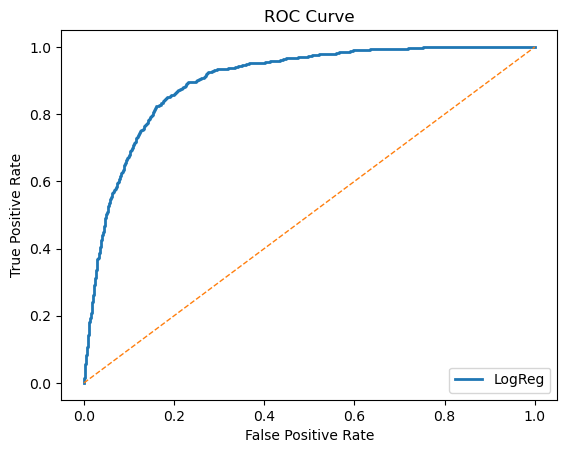

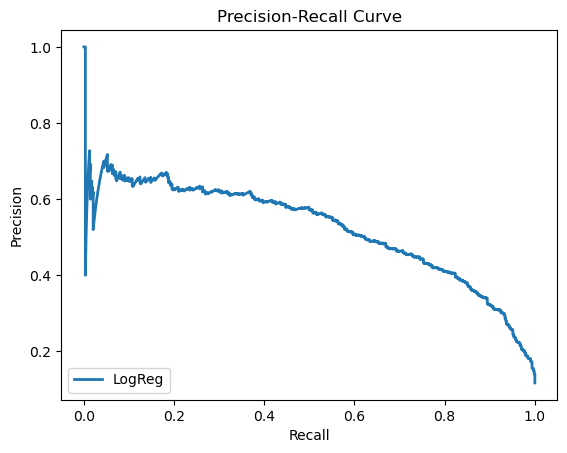

[RandomForest] best_params: {'clf__max_depth': 20, 'clf__n_estimators': 400}  ROC_AUC: 0.9227324198751924


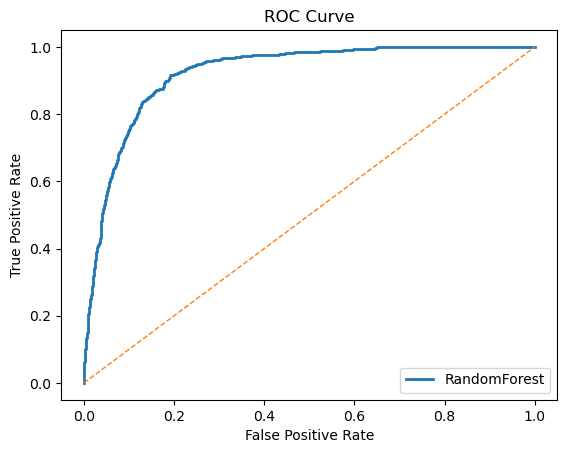

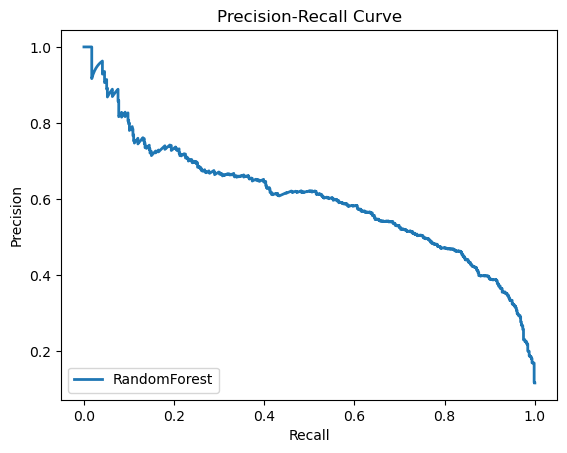

c:\Users\ssshu\anaconda3\Lib\site-packages\executing\executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
c:\Users\ssshu\anaconda3\Lib\ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)


KeyboardInterrupt: 

In [ ]:

# ==== 6. 学習・評価 ====
results = []

if not df.empty:
    # (A) ロジスティック回帰（L2）
    log_reg = Pipeline(steps=[
        ("pre", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ])
    log_reg_params = {
        "clf__C": [0.1, 1.0, 3.0]
    }
    log_reg_gs = GridSearchCV(log_reg, log_reg_params, cv=5, n_jobs=-1, scoring="roc_auc")
    log_reg_gs.fit(X_train, y_train)
    y_prob = log_reg_gs.predict_proba(X_test)[:,1]
    metrics = evaluate_binary_classification(y_test, y_prob)
    metrics.update({"model":"LogisticRegression", "best_params": str(log_reg_gs.best_params_)})
    results.append(metrics)
    print("[LogReg] best_params:", log_reg_gs.best_params_, " ROC_AUC:", metrics["roc_auc"])
    plot_roc(y_test, y_prob, label="LogReg")
    plot_pr(y_test, y_prob, label="LogReg")

    # (B) ランダムフォレスト
    rf = Pipeline(steps=[
        ("pre", preprocessor),
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE))
    ])
    rf_params = {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [None, 10, 20]
    }
    rf_gs = GridSearchCV(rf, rf_params, cv=5, n_jobs=-1, scoring="roc_auc")
    rf_gs.fit(X_train, y_train)
    y_prob = rf_gs.predict_proba(X_test)[:,1]
    metrics = evaluate_binary_classification(y_test, y_prob)
    metrics.update({"model":"RandomForest", "best_params": str(rf_gs.best_params_)})
    results.append(metrics)
    print("[RandomForest] best_params:", rf_gs.best_params_, " ROC_AUC:", metrics["roc_auc"])
    plot_roc(y_test, y_prob, label="RandomForest")
    plot_pr(y_test, y_prob, label="RandomForest")

    # (C) 勾配ブースティング（scikit-learn）
    gb = Pipeline(steps=[
        ("pre", preprocessor),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
    gb_params = {
        "clf__n_estimators": [100, 300],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [2, 3]
    }
    gb_gs = GridSearchCV(gb, gb_params, cv=5, n_jobs=-1, scoring="roc_auc")
    gb_gs.fit(X_train, y_train)
    y_prob = gb_gs.predict_proba(X_test)[:,1]
    metrics = evaluate_binary_classification(y_test, y_prob)
    metrics.update({"model":"GradientBoosting", "best_params": str(gb_gs.best_params_)})
    results.append(metrics)
    print("[GradientBoosting] best_params:", gb_gs.best_params_, " ROC_AUC:", metrics["roc_auc"])
    plot_roc(y_test, y_prob, label="GradientBoosting")
    plost_pr(y_test, y_prob, label="GradientBoosting")


### 6.x 追加モデルの準備（XGBoost / LightGBM / CatBoost）

In [ ]:

# XGBoost / LightGBM / CatBoost が導入されていれば使います（未導入でもNotebookは動きます）
HAS_XGB = HAS_LGBM = HAS_CAT = True
try:
    from xgboost import XGBClassifier
except Exception as e:
    HAS_XGB = False
    print("[INFO] XGBoost 未導入のためスキップ:", e)

try:
    from lightgbm import LGBMClassifier
except Exception as e:
    HAS_LGBM = False
    print("[INFO] LightGBM 未導入のためスキップ:", e)

try:
    from catboost import CatBoostClassifier
except Exception as e:
    HAS_CAT = False
    print("[INFO] CatBoost 未導入のためスキップ:", e)


#### (D) XGBoost

In [ ]:

if not df.empty and HAS_XGB:
    xgb = Pipeline(steps=[
        ("pre", preprocessor),
        ("clf", XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            random_state=RANDOM_STATE,
            n_estimators=300,
            learning_rate=0.1,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist"  # CPU高速化（環境により自動で切替）
        ))
    ])
    xgb_params = {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [3, 5],
        "clf__learning_rate": [0.05, 0.1]
    }
    xgb_gs = GridSearchCV(xgb, xgb_params, cv=5, n_jobs=-1, scoring="roc_auc")
    xgb_gs.fit(X_train, y_train)
    y_prob = xgb_gs.predict_proba(X_test)[:, 1]
    metrics = evaluate_binary_classification(y_test, y_prob)
    metrics.update({"model":"XGBoost", "best_params": str(xgb_gs.best_params_)})
    results.append(metrics)
    print("[XGBoost] best_params:", xgb_gs.best_params_, " ROC_AUC:", metrics["roc_auc"])
    plot_roc(y_test, y_prob, label="XGBoost")
    plot_pr(y_test, y_prob, label="XGBoost")


#### (E) LightGBM

In [ ]:

if not df.empty and HAS_LGBM:
    lgbm = Pipeline(steps=[
        ("pre", preprocessor),
        ("clf", LGBMClassifier(
            objective="binary",
            random_state=RANDOM_STATE,
            n_estimators=300,
            learning_rate=0.1,
            max_depth=-1
        ))
    ])
    lgbm_params = {
        "clf__n_estimators": [300, 500],
        "clf__num_leaves": [31, 63],
        "clf__learning_rate": [0.05, 0.1]
    }
    lgbm_gs = GridSearchCV(lgbm, lgbm_params, cv=5, n_jobs=-1, scoring="roc_auc")
    lgbm_gs.fit(X_train, y_train)
    y_prob = lgbm_gs.predict_proba(X_test)[:, 1]
    metrics = evaluate_binary_classification(y_test, y_prob)
    metrics.update({"model":"LightGBM", "best_params": str(lgbm_gs.best_params_)})
    results.append(metrics)
    print("[LightGBM] best_params:", lgbm_gs.best_params_, " ROC_AUC:", metrics["roc_auc"])
    plot_roc(y_test, y_prob, label="LightGBM")
    plot_pr(y_test, y_prob, label="LightGBM")


#### (F) CatBoost

In [ ]:

if not df.empty and HAS_CAT:
    # One-Hot後の数値を使うため、CatBoostもPipelineに入れて問題ありません
    catb = Pipeline(steps=[
        ("pre", preprocessor),
        ("clf", CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            random_state=RANDOM_STATE,
            verbose=0
        ))
    ])
    cat_params = {
        "clf__depth": [4, 6],
        "clf__learning_rate": [0.05, 0.1],
        "clf__n_estimators": [300, 600]
    }
    cat_gs = GridSearchCV(catb, cat_params, cv=5, n_jobs=-1, scoring="roc_auc")
    cat_gs.fit(X_train, y_train)
    y_prob = cat_gs.predict_proba(X_test)[:, 1]
    metrics = evaluate_binary_classification(y_test, y_prob)
    metrics.update({"model":"CatBoost", "best_params": str(cat_gs.best_params_)})
    results.append(metrics)
    print("[CatBoost] best_params:", cat_gs.best_params_, " ROC_AUC:", metrics["roc_auc"])
    plot_roc(y_test, y_prob, label="CatBoost")
    plot_pr(y_test, y_prob, label="CatBoost")


In [ ]:

# ==== 7. 比較サマリー & 保存 ====
if results:
    summary_df = pd.DataFrame(results)[["model","accuracy","precision","recall","f1","roc_auc","pr_auc","best_params"]]
    display(summary_df.sort_values("roc_auc", ascending=False).reset_index(drop=True))
    summary_df.to_csv("model_summary.csv", index=False)
    print("Saved: model_summary.csv")


## 8. 提出用予測出力（サブミット作成）
- 検証で最も良かったモデルを **全学習データで再学習** し、テストデータへ推論
- `submit_sample.csv` をベースに提出ファイルを作成

In [ ]:

# ==== 提出設定 ====
TEST_DATA_PATH = "data/test.csv"                # テストデータのパス（必要に応じて変更）
SUBMIT_SAMPLE_PATH = "./submit/submit_sample.csv"
OUTPUT_DIR = "./submit"
OUTPUT_FILE = f"submission_{__import__('datetime').datetime.now().strftime('%Y%m%d_%H%M')}.csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [ ]:

# 最良モデルの選定：検証ROC AUCが最大のもの
import numpy as np
if not results:
    raise RuntimeError("先に『6. 学習・評価』セルを実行してください。")
best_idx = int(np.argmax([r["roc_auc"] for r in results]))
best_name = results[best_idx]["model"]
print("Best model on validation:", best_name)


In [ ]:

# ベストモデルに対応する最適ハイパーパラメータを取得し、全データで再学習
if best_name == "LogisticRegression":
    best_params = log_reg_gs.best_params_
    final_model = Pipeline(steps=[
        ("pre", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **{k.split("__")[1]: v for k,v in best_params.items()}))
    ])
elif best_name == "RandomForest":
    best_params = rf_gs.best_params_
    final_model = Pipeline(steps=[
        ("pre", preprocessor),
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE, **{k.split("__")[1]: v for k,v in best_params.items()}))
    ])
else:  # GradientBoosting
    best_params = gb_gs.best_params_
    final_model = Pipeline(steps=[
        ("pre", preprocessor),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE, **{k.split("__")[1]: v for k,v in best_params.items()}))
    ])
print("Best params:", best_params)


In [ ]:

# 全データで再学習（学習用dfが空でない前提）
if df.empty:
    raise RuntimeError("学習用データが空です。『4〜6章』を確認してください。")
y_full = df[TARGET_COL].astype(int)
X_full = df.drop(columns=[TARGET_COL])
final_model.fit(X_full, y_full)


In [ ]:

# テストデータ読み込みと予測
if not os.path.exists(TEST_DATA_PATH):
    raise FileNotFoundError(f"テストデータが見つかりません: {TEST_DATA_PATH}")
test_df = pd.read_csv(TEST_DATA_PATH)
pred_proba = final_model.predict_proba(test_df)[:, 1]
print("Test shape:", test_df.shape, "  Proba preview:", pred_proba[:5])


In [ ]:

# 提出ファイル作成（submit_sample.csvを踏襲）
if not os.path.exists(SUBMIT_SAMPLE_PATH):
    raise FileNotFoundError(f"submit_sampleが見つかりません: {SUBMIT_SAMPLE_PATH}")
submit = pd.read_csv(SUBMIT_SAMPLE_PATH, header=None)
# 1列目がID、2列目が予測値を想定
submit[1] = pred_proba
out_path = os.path.join(OUTPUT_DIR, OUTPUT_FILE)
submit.to_csv(out_path, header=None, index=False)
print("Saved:", out_path)
